# Vehicle Type Classification
10-class vehicle body type classification using transfer learning (EfficientNet-B2).

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import EfficientNet_B2_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tqdm.notebook import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


(null): No such file or directory


In [2]:
BASE_DIR = Path(".")
TRAIN_DIR = BASE_DIR / "data" / "train"
TEST_DIR = BASE_DIR / "data" / "test"
SUBMISSIONS_DIR = BASE_DIR / "submissions"
SUBMISSIONS_DIR.mkdir(exist_ok=True)

CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: cls for cls, i in CLASS_TO_IDX.items()}

print(f"Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")
print(f"Train images: {sum(len(list((TRAIN_DIR / c).glob('*'))) for c in CLASS_NAMES)}")
print(f"Test images:  {len(list(TEST_DIR.glob('*.jpg')))}")

Classes (10): ['SUV', 'bus', 'convertible', 'coupes', 'hatchback', 'pickup', 'sedan', 'station_wagon', 'trucks', 'van']
Train images: 802
Test images:  200


## EDA

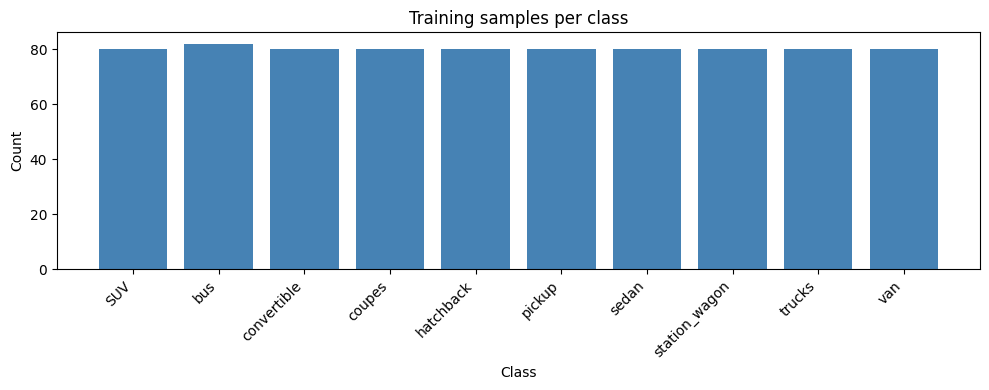

In [3]:
class_counts = {cls: len(list((TRAIN_DIR / cls).glob("*"))) for cls in CLASS_NAMES}

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(class_counts.keys(), class_counts.values(), color="steelblue")
ax.set_title("Training samples per class")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

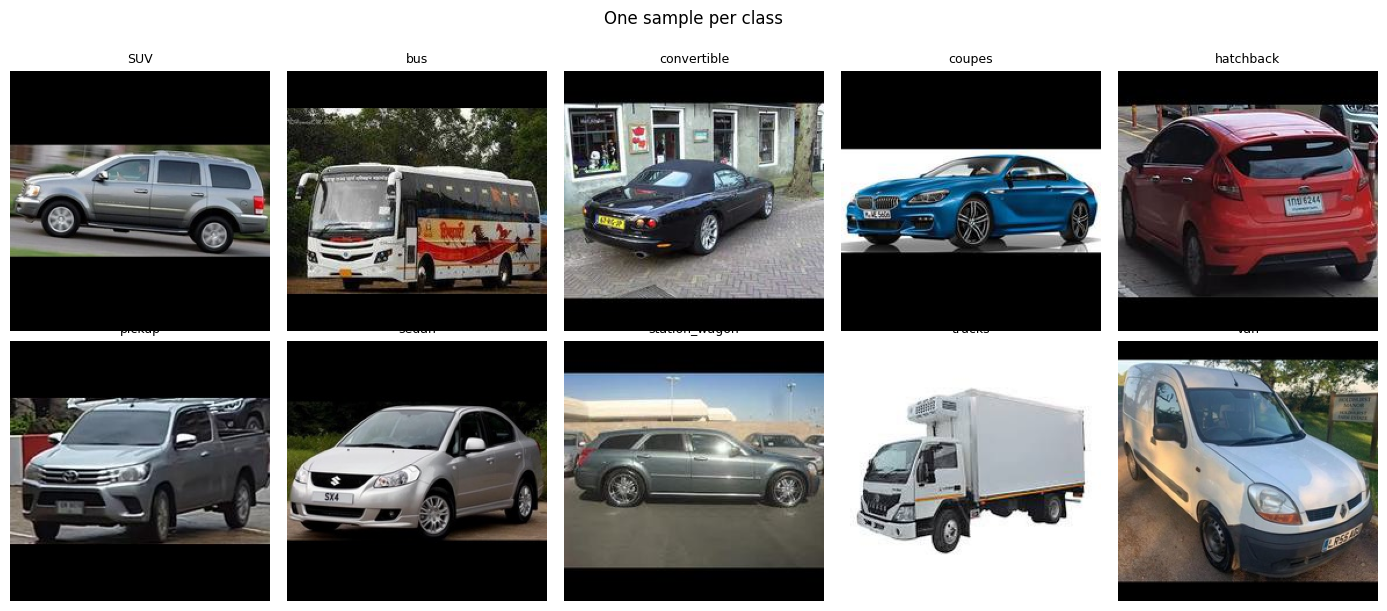

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, cls in zip(axes.flat, CLASS_NAMES):
    imgs = list((TRAIN_DIR / cls).glob("*.jpg"))
    img = Image.open(random.choice(imgs))
    ax.imshow(img)
    ax.set_title(cls, fontsize=9)
    ax.axis("off")
plt.suptitle("One sample per class", y=1.01)
plt.tight_layout()
plt.show()

## Dataset & DataLoaders

In [5]:
class VehicleDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples  # list of (path_str, label_int)
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


class TestDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        # case-insensitive extension match (avoids missing .JPG etc.)
        self.paths = sorted(
            p for p in Path(test_dir).iterdir()
            if p.suffix.lower() in (".jpg", ".jpeg", ".png")
        )
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, path.name

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Build sample list and stratified split
all_paths, all_labels = [], []
for cls in CLASS_NAMES:
    for p in (TRAIN_DIR / cls).glob("*.jpg"):
        all_paths.append(str(p))
        all_labels.append(CLASS_TO_IDX[cls])

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, stratify=all_labels, random_state=SEED
)

train_ds = VehicleDataset(list(zip(train_paths, train_labels)), transform=train_transform)
val_ds   = VehicleDataset(list(zip(val_paths,   val_labels)),   transform=val_transform)

BATCH_SIZE = 32
# num_workers=0: Dataset classes defined in notebook cells can't be pickled by worker processes
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Train: 634 | Val: 159


## Model — EfficientNet-B2 (pretrained)

In [7]:
def build_model(num_classes: int = 10, freeze_backbone: bool = True) -> nn.Module:
    model = models.efficientnet_b2(weights=EfficientNet_B2_Weights.DEFAULT)
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

model = build_model(num_classes=len(CLASS_NAMES), freeze_backbone=True).to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Total: {total:,} | Trainable: {trainable:,} (backbone frozen)")

Total: 7,715,084 | Trainable: 14,090 (backbone frozen)


## Training

In [8]:
CHECKPOINT = "best_model.pth"
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [9]:
def run_epoch(model, loader, criterion, optimizer, device, train: bool):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += len(labels)
    return total_loss / total, correct / total


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

# ── Phase 1: frozen backbone, train head only ──────────────────────────────
PHASE1_EPOCHS = 15
opt1 = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-2, weight_decay=1e-4)
sch1 = optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=PHASE1_EPOCHS, eta_min=1e-4)

print("=== Phase 1: head only (backbone frozen) ===")
for epoch in range(1, PHASE1_EPOCHS + 1):
    tl, ta = run_epoch(model, train_loader, criterion, opt1, device, train=True)
    vl, va = run_epoch(model, val_loader,   criterion, None, device, train=False)
    sch1.step()
    history["train_loss"].append(tl); history["val_loss"].append(vl)
    history["train_acc"].append(ta);  history["val_acc"].append(va)
    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), CHECKPOINT)
    print(f"  {epoch:2d}/{PHASE1_EPOCHS} | train {ta:.4f} | val {va:.4f}" + (" ✓" if va == best_val_acc else ""))

# ── Phase 2: unfreeze last 3 backbone blocks, fine-tune with low LR ────────
print("\n=== Phase 2: fine-tuning last backbone blocks ===")
for param in model.features[6:].parameters():
    param.requires_grad = True

backbone_params = [p for n, p in model.named_parameters() if p.requires_grad and "classifier" not in n]
head_params     = list(model.classifier.parameters())
opt2 = optim.AdamW([
    {"params": backbone_params, "lr": 1e-4},
    {"params": head_params,     "lr": 5e-4},
], weight_decay=1e-4)

PHASE2_EPOCHS = 20
sch2 = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=PHASE2_EPOCHS, eta_min=1e-6)

for epoch in range(1, PHASE2_EPOCHS + 1):
    tl, ta = run_epoch(model, train_loader, criterion, opt2, device, train=True)
    vl, va = run_epoch(model, val_loader,   criterion, None, device, train=False)
    sch2.step()
    history["train_loss"].append(tl); history["val_loss"].append(vl)
    history["train_acc"].append(ta);  history["val_acc"].append(va)
    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), CHECKPOINT)
    print(f"  {epoch:2d}/{PHASE2_EPOCHS} | train {ta:.4f} | val {va:.4f}" + (" ✓" if va == best_val_acc else ""))

print(f"\nBest val acc: {best_val_acc:.4f}")

=== Phase 1: head only (backbone frozen) ===
   1/15 | train 0.3659 | val 0.6038 ✓
   2/15 | train 0.6104 | val 0.6164 ✓
   3/15 | train 0.6420 | val 0.7044 ✓
   4/15 | train 0.7050 | val 0.6981
   5/15 | train 0.7129 | val 0.6792
   6/15 | train 0.7003 | val 0.6415
   7/15 | train 0.7192 | val 0.6730
   8/15 | train 0.7224 | val 0.6981
   9/15 | train 0.7666 | val 0.6981
  10/15 | train 0.7461 | val 0.7170 ✓
  11/15 | train 0.7508 | val 0.7233 ✓
  12/15 | train 0.7413 | val 0.6981
  13/15 | train 0.7776 | val 0.7170
  14/15 | train 0.7871 | val 0.7170
  15/15 | train 0.7634 | val 0.7170

=== Phase 2: fine-tuning last backbone blocks ===
   1/20 | train 0.7650 | val 0.7233 ✓
   2/20 | train 0.7965 | val 0.7358 ✓
   3/20 | train 0.8170 | val 0.7610 ✓
   4/20 | train 0.8344 | val 0.7736 ✓
   5/20 | train 0.8454 | val 0.7610
   6/20 | train 0.8691 | val 0.7925 ✓
   7/20 | train 0.8927 | val 0.7799
   8/20 | train 0.8864 | val 0.7736
   9/20 | train 0.8959 | val 0.7673
  10/20 | train 0.88

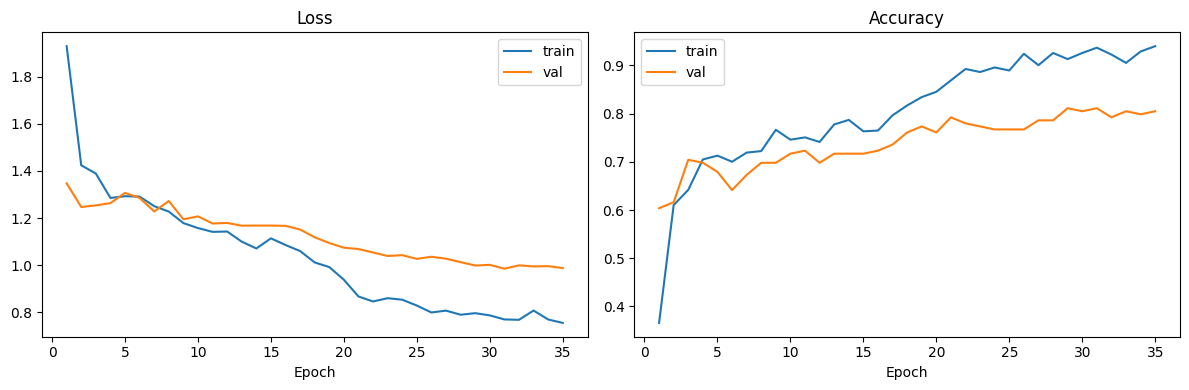

In [10]:
epochs = range(1, len(history["train_acc"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history["train_loss"], label="train")
ax1.plot(epochs, history["val_loss"],   label="val")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(epochs, history["train_acc"], label="train")
ax2.plot(epochs, history["val_acc"],   label="val")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

## Evaluation

In [11]:
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        preds = model(imgs.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

print(classification_report(all_true, all_preds, target_names=CLASS_NAMES))

               precision    recall  f1-score   support

          SUV       1.00      0.81      0.90        16
          bus       1.00      0.94      0.97        16
  convertible       0.62      0.50      0.55        16
       coupes       0.53      0.62      0.57        16
    hatchback       1.00      0.88      0.93        16
       pickup       1.00      0.94      0.97        16
        sedan       0.58      0.88      0.70        16
station_wagon       0.69      0.69      0.69        16
       trucks       1.00      0.93      0.97        15
          van       0.94      0.94      0.94        16

     accuracy                           0.81       159
    macro avg       0.84      0.81      0.82       159
 weighted avg       0.83      0.81      0.82       159



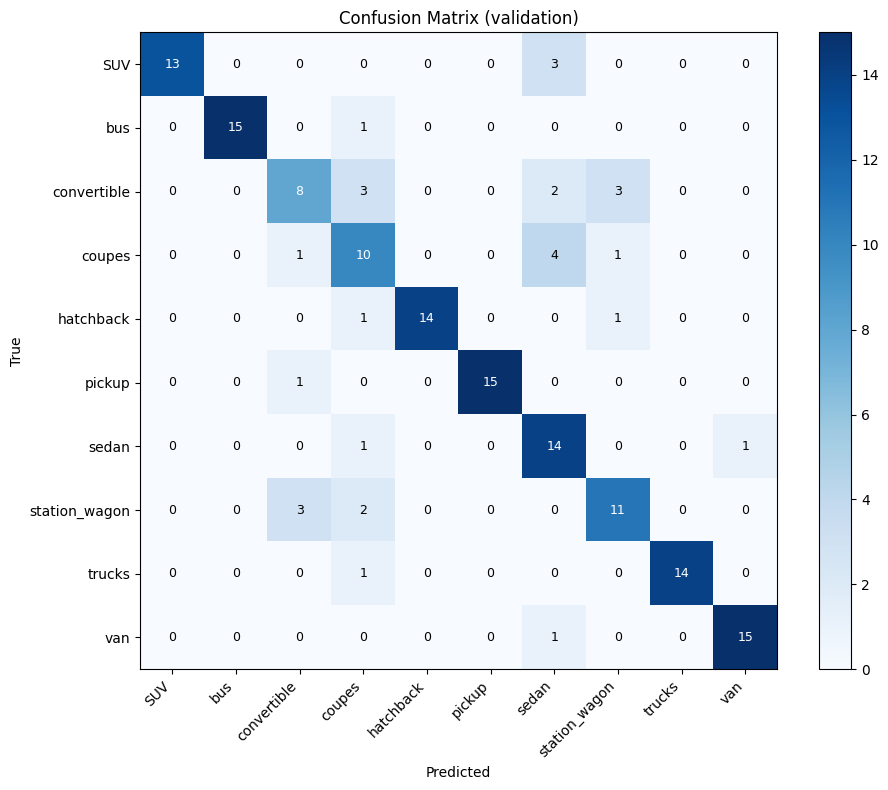

In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (validation)")
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=9)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Inference & Submission

In [13]:
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.eval()

# Test-time augmentation: average predictions over 3 views
tta_transforms_list = [
    val_transform,
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),  # always flip
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
]

test_paths = sorted(p for p in Path(TEST_DIR).iterdir() if p.suffix.lower() in (".jpg", ".jpeg", ".png"))
names = [p.name for p in test_paths]

all_probs = []
for t in tta_transforms_list:
    ds = TestDataset(TEST_DIR, transform=t)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    batch_probs = []
    with torch.no_grad():
        for imgs, _ in loader:
            p = torch.softmax(model(imgs.to(device)), dim=1).cpu()
            batch_probs.append(p)
    all_probs.append(torch.cat(batch_probs, dim=0))

avg_probs = torch.stack(all_probs).mean(0)
preds = avg_probs.argmax(1).numpy()

results = [{"image_name": n, "ground_truth": IDX_TO_CLASS[int(p)]} for n, p in zip(names, preds)]
submission = pd.DataFrame(results).sort_values("image_name").reset_index(drop=True)
out_path = SUBMISSIONS_DIR / "submission_efficientnet_b2_staged.csv"
submission.to_csv(out_path, index=False)
print(f"Saved {len(submission)} predictions → {out_path}")
submission.head(10)

Saved 201 predictions → submissions/submission_efficientnet_b2_staged.csv


,image_name,ground_truth
0,0009.jpg,station_wagon
1,0013.jpg,bus
2,0024.jpg,bus
3,0028.jpg,station_wagon
4,0034.jpg,station_wagon
5,0047.jpg,trucks
6,0051.jpg,convertible
7,0056.jpg,station_wagon
8,0065.jpg,bus
9,0067.jpg,bus


In [9]:
# ── Feature extraction helpers ────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def make_extractor(model_fn, weights, head_attr):
    """Return a frozen backbone with the classifier head removed."""
    m = model_fn(weights=weights)
    setattr(m, head_attr, nn.Identity())
    m = m.to(device).eval()
    for p in m.parameters():
        p.requires_grad = False
    return m

def extract_with_transform(paths, extractor, t):
    """Extract feature matrix for a list of image paths using transform t."""
    class _DS(Dataset):
        def __len__(self): return len(paths)
        def __getitem__(self, i):
            return t(Image.open(paths[i]).convert("RGB"))
    loader = DataLoader(_DS(), batch_size=64, shuffle=False, num_workers=0)
    feats = []
    with torch.no_grad():
        for imgs in loader:
            feats.append(extractor(imgs.to(device)).cpu().numpy())
    return np.vstack(feats)

def extract_tta(paths, extractor, transforms_list):
    """Average features over multiple augmented views (feature-level TTA)."""
    views = [extract_with_transform(paths, extractor, t) for t in transforms_list]
    return np.mean(views, axis=0)

# TTA views: original resize, hflip, center-crop from 256, hflip+crop
tta_ts = [
    val_transform,
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(p=1.0),
                        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),
                        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),
                        transforms.RandomHorizontalFlip(p=1.0),
                        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
]

In [11]:
# ── EfficientNet-B2 features (with TTA) ───────────────────────────────────
from torchvision.models import EfficientNet_B2_Weights

eff_extractor = make_extractor(models.efficientnet_b2, EfficientNet_B2_Weights.DEFAULT, "classifier")

all_train_paths = train_paths + val_paths
all_train_labels = np.array(train_labels + val_labels)
test_paths_list = [str(p) for p in sorted(
    p for p in Path(TEST_DIR).iterdir() if p.suffix.lower() in (".jpg", ".jpeg", ".png")
)]
test_names = [Path(p).name for p in test_paths_list]

print("EfficientNet: extracting train+val features (TTA)...")
X_eff_all   = extract_tta(all_train_paths, eff_extractor, tta_ts)
X_eff_train = X_eff_all[:len(train_paths)]
X_eff_val   = X_eff_all[len(train_paths):]

print("EfficientNet: extracting test features (TTA)...")
X_eff_test = extract_tta(test_paths_list, eff_extractor, tta_ts)

pipe_eff = Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, C=10.0, random_state=SEED))])
pipe_eff.fit(X_eff_train, train_labels)
print(f"EfficientNet+TTA val acc: {pipe_eff.score(X_eff_val, val_labels):.4f}")

EfficientNet: extracting train+val features (TTA)...
EfficientNet: extracting test features (TTA)...
EfficientNet+TTA val acc: 0.9119


In [12]:
import os
os.environ["TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL"] = "1"

In [13]:
# ── ViT-B/16 features (with TTA) ──────────────────────────────────────────
from torchvision.models import vit_b_16, ViT_B_16_Weights

vit_extractor = make_extractor(vit_b_16, ViT_B_16_Weights.DEFAULT, "heads")

print("ViT: extracting train+val features (TTA)...")
X_vit_all   = extract_tta(all_train_paths, vit_extractor, tta_ts)
X_vit_train = X_vit_all[:len(train_paths)]
X_vit_val   = X_vit_all[len(train_paths):]

print("ViT: extracting test features (TTA)...")
X_vit_test = extract_tta(test_paths_list, vit_extractor, tta_ts)

pipe_vit = Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, C=10.0, random_state=SEED))])
pipe_vit.fit(X_vit_train, train_labels)
print(f"ViT-B/16+TTA val acc: {pipe_vit.score(X_vit_val, val_labels):.4f}")

ViT: extracting train+val features (TTA)...
ViT: extracting test features (TTA)...
ViT-B/16+TTA val acc: 0.9057


In [14]:
# ── Ensemble: concatenate EfficientNet + ViT features ─────────────────────
X_concat_train = np.hstack([X_eff_train, X_vit_train])
X_concat_val   = np.hstack([X_eff_val,   X_vit_val])
X_concat_test  = np.hstack([X_eff_test,  X_vit_test])

pipe_ensemble = Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, C=10.0, random_state=SEED))])
pipe_ensemble.fit(X_concat_train, train_labels)
val_acc = pipe_ensemble.score(X_concat_val, val_labels)
print(f"Ensemble (Eff+ViT) val acc: {val_acc:.4f}")

# Submission
preds = pipe_ensemble.predict(X_concat_test)
results = [{"image_name": n, "ground_truth": IDX_TO_CLASS[int(p)]} for n, p in zip(test_names, preds)]
submission = pd.DataFrame(results).sort_values("image_name").reset_index(drop=True)
out_path = SUBMISSIONS_DIR / "submission_ensemble_eff_vit.csv"
submission.to_csv(out_path, index=False)
print(f"Saved {len(submission)} predictions → {out_path}")
submission.head(10)

Ensemble (Eff+ViT) val acc: 0.9308
Saved 201 predictions → submissions/submission_ensemble_eff_vit.csv


,image_name,ground_truth
0,0009.jpg,bus
1,0013.jpg,bus
2,0024.jpg,bus
3,0028.jpg,bus
4,0034.jpg,bus
5,0047.jpg,trucks
6,0051.jpg,bus
7,0056.jpg,bus
8,0065.jpg,trucks
9,0067.jpg,bus


## Full-dataset ensemble (train + val, no split)

In [15]:
VALID_EXTS = {".jpg", ".jpeg", ".png", ".webp"}

full_paths, full_labels = [], []
for cls in CLASS_NAMES:
    for p in sorted((TRAIN_DIR / cls).iterdir()):
        if p.suffix.lower() in VALID_EXTS:
            full_paths.append(str(p))
            full_labels.append(CLASS_TO_IDX[cls])
full_labels = np.array(full_labels)

test_paths_full = [str(p) for p in sorted(
    p for p in Path(TEST_DIR).iterdir() if p.suffix.lower() in VALID_EXTS
)]
test_names_full = [Path(p).name for p in test_paths_full]

print(f"Full train: {len(full_paths)} images | Test: {len(test_paths_full)} images")

Full train: 802 images | Test: 201 images


In [16]:
print("EfficientNet: extracting full-train features (TTA)...")
X_eff_full = extract_tta(full_paths, eff_extractor, tta_ts)

print("EfficientNet: extracting test features (TTA)...")
X_eff_test_full = extract_tta(test_paths_full, eff_extractor, tta_ts)

print("ViT: extracting full-train features (TTA)...")
X_vit_full = extract_tta(full_paths, vit_extractor, tta_ts)

print("ViT: extracting test features (TTA)...")
X_vit_test_full = extract_tta(test_paths_full, vit_extractor, tta_ts)

print("Done.")

EfficientNet: extracting full-train features (TTA)...
EfficientNet: extracting test features (TTA)...
ViT: extracting full-train features (TTA)...
ViT: extracting test features (TTA)...
Done.


In [17]:
X_concat_full = np.hstack([X_eff_full, X_vit_full])
X_concat_test_full = np.hstack([X_eff_test_full, X_vit_test_full])

pipe_full = Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, C=10.0, random_state=SEED))])
pipe_full.fit(X_concat_full, full_labels)
print("Fitted on full training set.")

preds_full = pipe_full.predict(X_concat_test_full)
results_full = [{"image_name": n, "ground_truth": IDX_TO_CLASS[int(p)]} for n, p in zip(test_names_full, preds_full)]
submission_full = pd.DataFrame(results_full).sort_values("image_name").reset_index(drop=True)
out_path = SUBMISSIONS_DIR / "submission_fulldata_ensemble.csv"
submission_full.to_csv(out_path, index=False)
print(f"Saved {len(submission_full)} predictions → {out_path}")
submission_full.head(10)

Fitted on full training set.
Saved 201 predictions → submissions/submission_fulldata_ensemble.csv


,image_name,ground_truth
0,0009.jpg,bus
1,0013.jpg,bus
2,0024.jpg,bus
3,0028.jpg,bus
4,0034.jpg,bus
5,0047.jpg,trucks
6,0051.jpg,bus
7,0056.jpg,bus
8,0065.jpg,trucks
9,0067.jpg,bus
